# Analyse exploratoire des modèles et des résultats

## 1) Configuration et chargement des données
Ce notebook analyse automatiquement les résultats des modèles entraînés.

Il lit les fichiers dans `results/` et `models/`, puis produit:
- un tableau comparatif des performances
- des graphiques de comparaison
- des courbes d'apprentissage

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for _ in range(6):
        if (current / 'results').exists() and (current / 'models').exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError("Impossible de trouver la racine du projet (dossiers 'results' et 'models').")

project_root = find_project_root(Path.cwd())
results_dir = project_root / 'results'
models_dir = project_root / 'models'

print(f'Project root: {project_root}')
print(f'Results dir:  {results_dir}')
print(f'Models dir:   {models_dir}')

Project root: C:\Users\AXELL\Desktop\nahla hl\projet
Results dir:  C:\Users\AXELL\Desktop\nahla hl\projet\results
Models dir:   C:\Users\AXELL\Desktop\nahla hl\projet\models


## 2) Tableau comparatif des modèles

In [2]:
def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

records = []
for metrics_file in sorted(results_dir.glob('*_metrics.json')):
    model_name = metrics_file.name.replace('_metrics.json', '')
    data = load_json(metrics_file)
    records.append({
        'model': model_name,
        'accuracy': data.get('accuracy'),
        'f1_weighted': data.get('f1_weighted'),
        'f1_macro': data.get('f1_macro'),
        'precision_weighted': data.get('precision_weighted'),
        'recall_weighted': data.get('recall_weighted'),
        'auc_macro': data.get('auc_macro'),
        'inference_time_ms': data.get('inference_time_per_sample_ms')
    })

df_metrics = pd.DataFrame(records)
df_metrics = df_metrics.sort_values('f1_weighted', ascending=False).reset_index(drop=True)

df_metrics

,model,accuracy,f1_weighted,f1_macro,precision_weighted,recall_weighted,auc_macro,inference_time_ms
0,ensemble_mlp_rf,0.995329,0.995727,0.922843,0.996475,0.995329,0.995701,0.019661
1,random_forest,0.739556,0.643367,0.439695,0.619559,0.739556,0.498704,0.014056
2,cnn,0.748444,0.640763,0.428063,0.560169,0.748444,0.507121,0.057313
3,hybrid,0.748444,0.640763,0.428063,0.560169,0.748444,0.500665,0.079436
4,lstm,0.748444,0.640763,0.428063,0.560169,0.748444,0.500838,0.053947
5,xgboost,0.743111,0.638955,0.428000,0.577293,0.743111,0.488171,0.001267
6,svm,0.255111,0.108488,0.206295,0.811950,0.255111,0.484394,0.455819


## 3) Visualisations comparatives

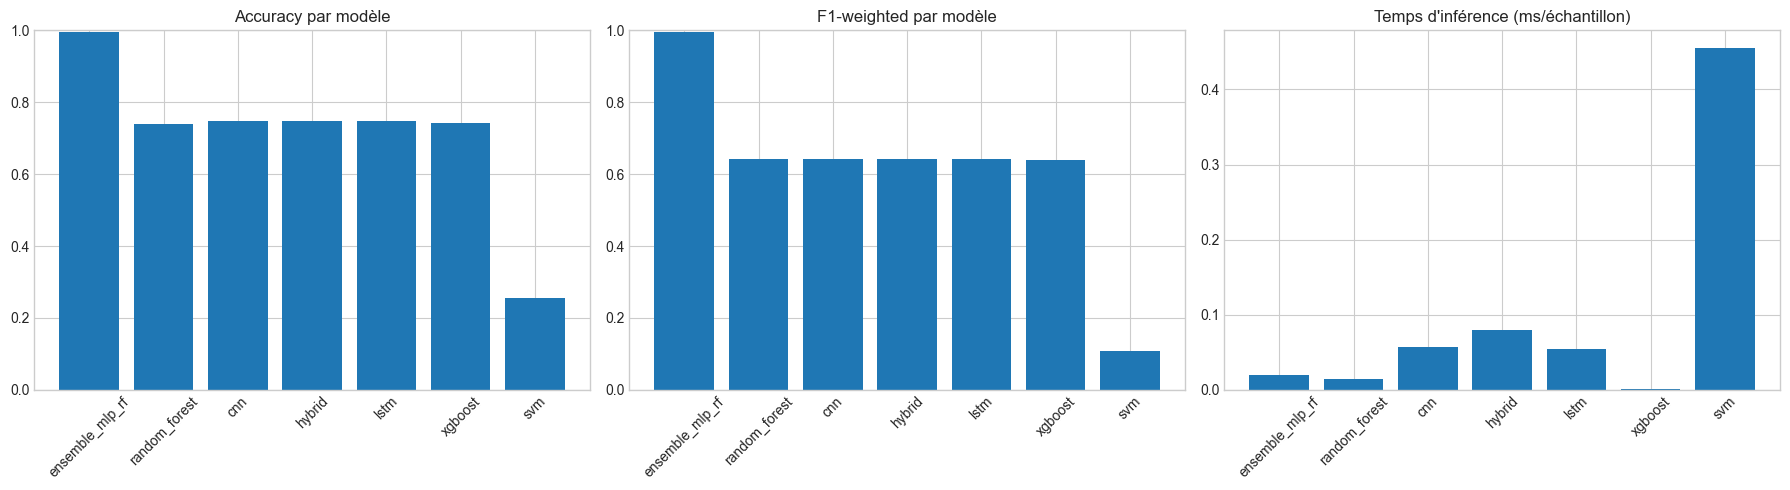

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].bar(df_metrics['model'], df_metrics['accuracy'])
axes[0].set_title('Accuracy par modèle')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# F1 weighted
axes[1].bar(df_metrics['model'], df_metrics['f1_weighted'])
axes[1].set_title('F1-weighted par modèle')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

# Inference time
axes[2].bar(df_metrics['model'], df_metrics['inference_time_ms'])
axes[2].set_title('Temps d\'inférence (ms/échantillon)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4) Analyse de la classe Malicious
Cette cellule vérifie la capacité réelle de détection des attaques (recall de la classe Malicious).

In [4]:
malicious_rows = []
for metrics_file in sorted(results_dir.glob('*_metrics.json')):
    model_name = metrics_file.name.replace('_metrics.json', '')
    data = load_json(metrics_file)
    cls_report = data.get('classification_report', {})
    malicious = cls_report.get('Malicious', {})
    malicious_rows.append({
        'model': model_name,
        'malicious_precision': malicious.get('precision'),
        'malicious_recall': malicious.get('recall'),
        'malicious_f1': malicious.get('f1-score'),
        'malicious_support': malicious.get('support')
    })

df_malicious = pd.DataFrame(malicious_rows).sort_values('malicious_recall', ascending=False)
df_malicious

,model,malicious_precision,malicious_recall,malicious_f1,malicious_support
5,svm,0.252453,1.000000,0.403134,566.0
4,random_forest,0.236842,0.015901,0.029801,566.0
6,xgboost,0.071429,0.001767,0.003448,566.0
0,cnn,0.000000,0.000000,0.000000,566.0
2,hybrid,0.000000,0.000000,0.000000,566.0
3,lstm,0.000000,0.000000,0.000000,566.0
1,ensemble_mlp_rf,NaN,NaN,NaN,NaN


## 5) Courbes d'apprentissage (historique des modèles)

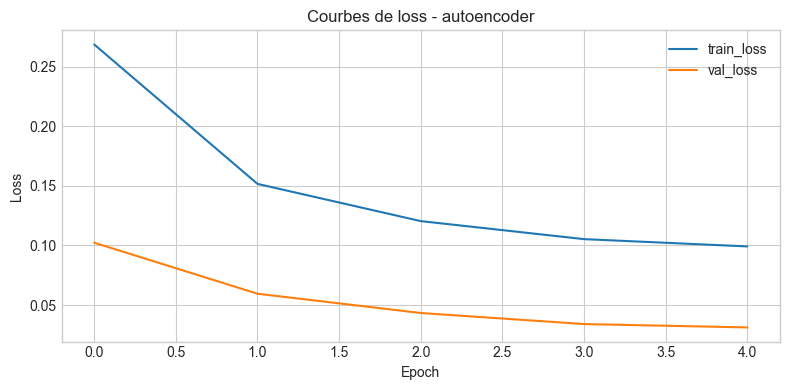

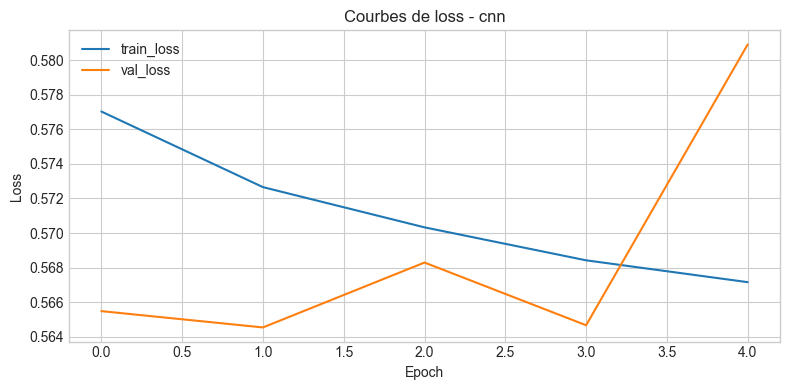

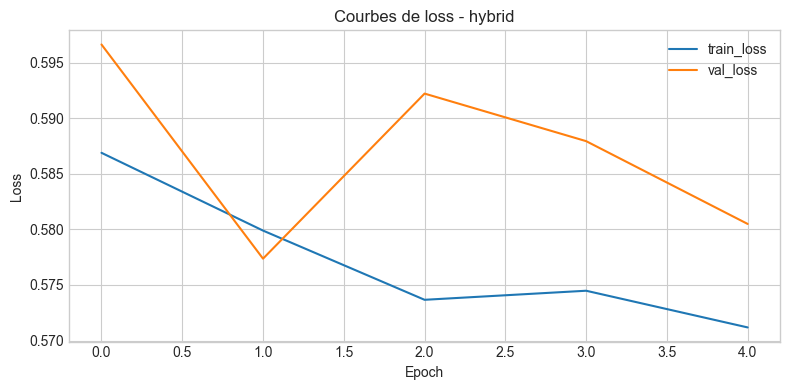

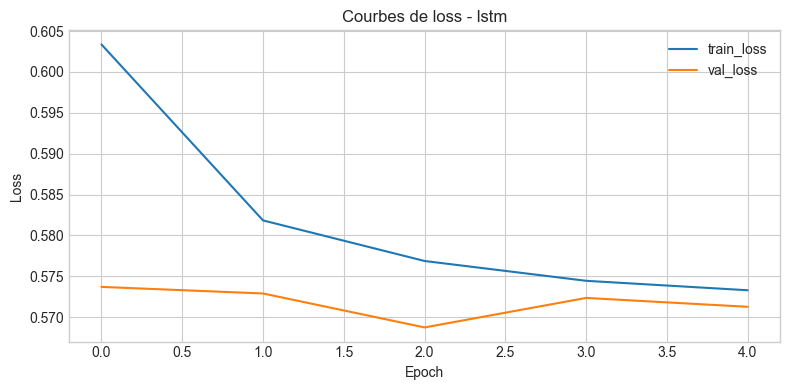

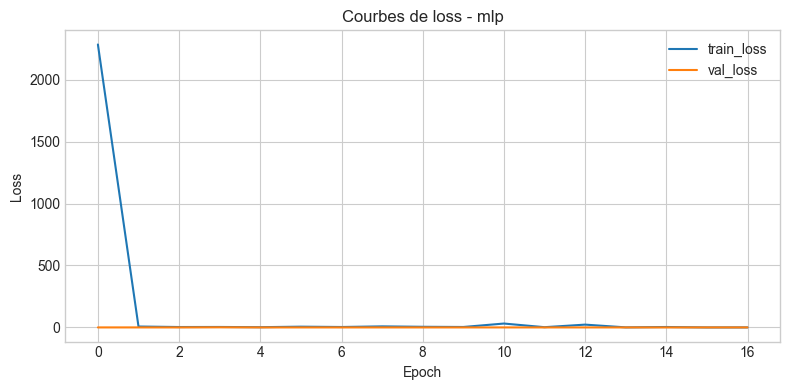

In [5]:
history_files = sorted(models_dir.glob('*_history.json'))

if not history_files:
    print('Aucun fichier *_history.json trouvé dans models/.')
else:
    for hf in history_files:
        model_name = hf.name.replace('_history.json', '')
        hist = load_json(hf)

        train_loss = hist.get('train_loss', [])
        val_loss = hist.get('val_loss', [])

        if not train_loss and not val_loss:
            continue

        plt.figure(figsize=(8, 4))
        if train_loss:
            plt.plot(train_loss, label='train_loss')
        if val_loss:
            plt.plot(val_loss, label='val_loss')

        plt.title(f'Courbes de loss - {model_name}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        plt.show()

## 6) Synthèse automatique
Cette cellule génère une synthèse textuelle rapide des meilleurs modèles.

In [6]:
best_f1 = df_metrics.loc[df_metrics['f1_weighted'].idxmax()]
best_acc = df_metrics.loc[df_metrics['accuracy'].idxmax()]
fastest = df_metrics.loc[df_metrics['inference_time_ms'].idxmin()]

print('=== Synthèse des performances ===')
print(f"Meilleur F1-weighted : {best_f1['model']} ({best_f1['f1_weighted']:.4f})")
print(f"Meilleure Accuracy   : {best_acc['model']} ({best_acc['accuracy']:.4f})")
print(f"Modèle le plus rapide: {fastest['model']} ({fastest['inference_time_ms']:.4f} ms/échantillon)")

if 'malicious_recall' in df_malicious.columns and not df_malicious['malicious_recall'].isna().all():
    best_attack = df_malicious.loc[df_malicious['malicious_recall'].idxmax()]
    print(f"Meilleur recall sur classe Malicious: {best_attack['model']} ({best_attack['malicious_recall']:.4f})")
else:
    print('Recall classe Malicious indisponible dans les fichiers de métriques.')

=== Synthèse des performances ===
Meilleur F1-weighted : ensemble_mlp_rf (0.9957)
Meilleure Accuracy   : ensemble_mlp_rf (0.9953)
Modèle le plus rapide: xgboost (0.0013 ms/échantillon)
Meilleur recall sur classe Malicious: svm (1.0000)


## Figure 2.2 : Distribution des classes (trafic normal vs attaque)
Cette figure est construite a partir d'un fichier de metriques binaire (Benign vs Malicious) present dans le dossier `results/`.

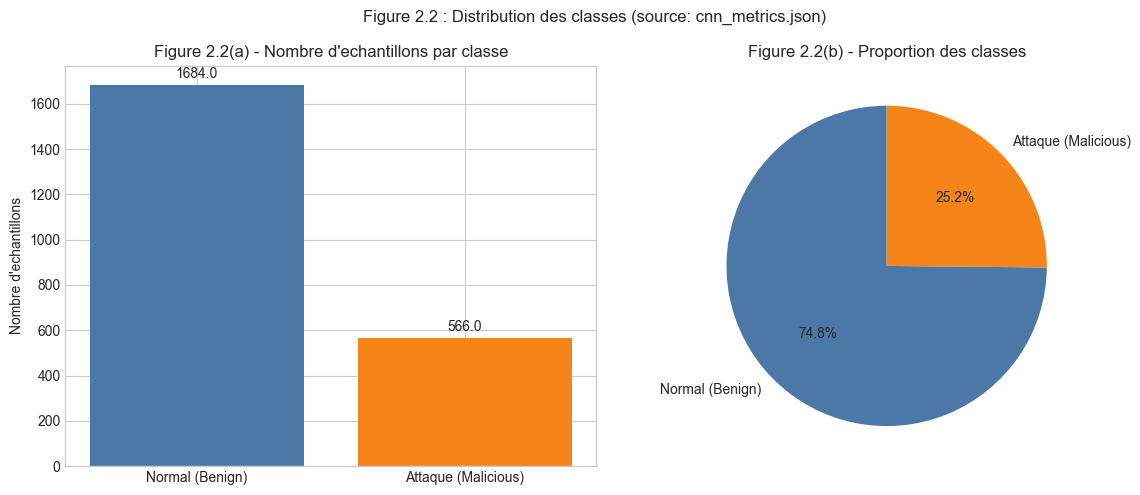

In [7]:
binary_metrics_file = None
binary_support = None

for mf in sorted(results_dir.glob('*_metrics.json')):
    d = load_json(mf)
    report = d.get('classification_report', {})
    if 'Benign' in report and 'Malicious' in report:
        benign_support = report['Benign'].get('support', 0)
        malicious_support = report['Malicious'].get('support', 0)
        binary_metrics_file = mf.name
        binary_support = {'Normal (Benign)': benign_support, 'Attaque (Malicious)': malicious_support}
        break

if binary_support is None:
    raise ValueError("Aucun fichier binaire Benign/Malicious trouvé dans results/*_metrics.json")

labels = list(binary_support.keys())
values = list(binary_support.values())
colors = ['#4C78A8', '#F58518']

total = sum(values)
percentages = [v * 100 / total for v in values]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, values, color=colors)
axes[0].set_title('Figure 2.2(a) - Nombre d\'echantillons par classe')
axes[0].set_ylabel('Nombre d\'echantillons')
for i, v in enumerate(values):
    axes[0].text(i, v + max(values) * 0.01, f"{v}", ha='center', va='bottom', fontsize=10)

axes[1].pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Figure 2.2(b) - Proportion des classes')

plt.suptitle(f"Figure 2.2 : Distribution des classes (source: {binary_metrics_file})", fontsize=12)
plt.tight_layout()
plt.show()

## Figure 2.3 : Etapes du pipeline de pretraitement des donnees IoT
Schema du pipeline utilise avant l'entrainement des modeles.

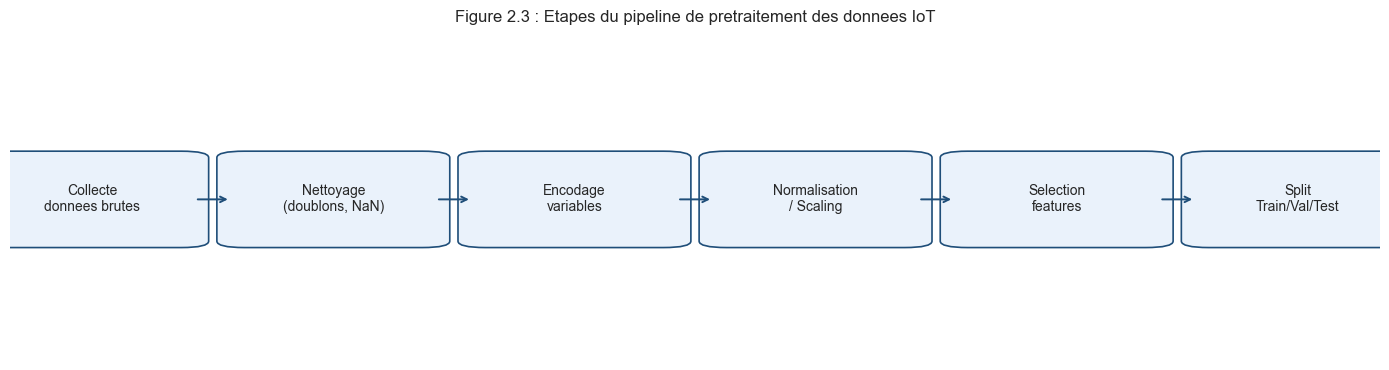

In [8]:
from matplotlib.patches import FancyBboxPatch

steps = [
    'Collecte\ndonnees brutes',
    'Nettoyage\n(doublons, NaN)',
    'Encodage\nvariables',
    'Normalisation\n/ Scaling',
    'Selection\nfeatures',
    'Split\nTrain/Val/Test'
]

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

x_positions = np.linspace(0.06, 0.94, len(steps))
box_w, box_h = 0.13, 0.26

for i, (x, text) in enumerate(zip(x_positions, steps)):
    box = FancyBboxPatch(
        (x - box_w / 2, 0.5 - box_h / 2),
        box_w,
        box_h,
        boxstyle='round,pad=0.02,rounding_size=0.02',
        linewidth=1.2,
        edgecolor='#1F4E79',
        facecolor='#EAF2FB'
    )
    ax.add_patch(box)
    ax.text(x, 0.5, text, ha='center', va='center', fontsize=10)

    if i < len(steps) - 1:
        x_next = x_positions[i + 1]
        ax.annotate(
            '',
            xy=(x_next - box_w / 2 - 0.01, 0.5),
            xytext=(x + box_w / 2 + 0.01, 0.5),
            arrowprops=dict(arrowstyle='->', lw=1.4, color='#1F4E79')
        )

ax.set_title('Figure 2.3 : Etapes du pipeline de pretraitement des donnees IoT', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

## Figure 2.4 : Architecture du modele de Deep Learning propose (DNN/LSTM hybride)
Schema fonctionnel de l'architecture hybride utilisee pour la detection d'intrusions IoT.

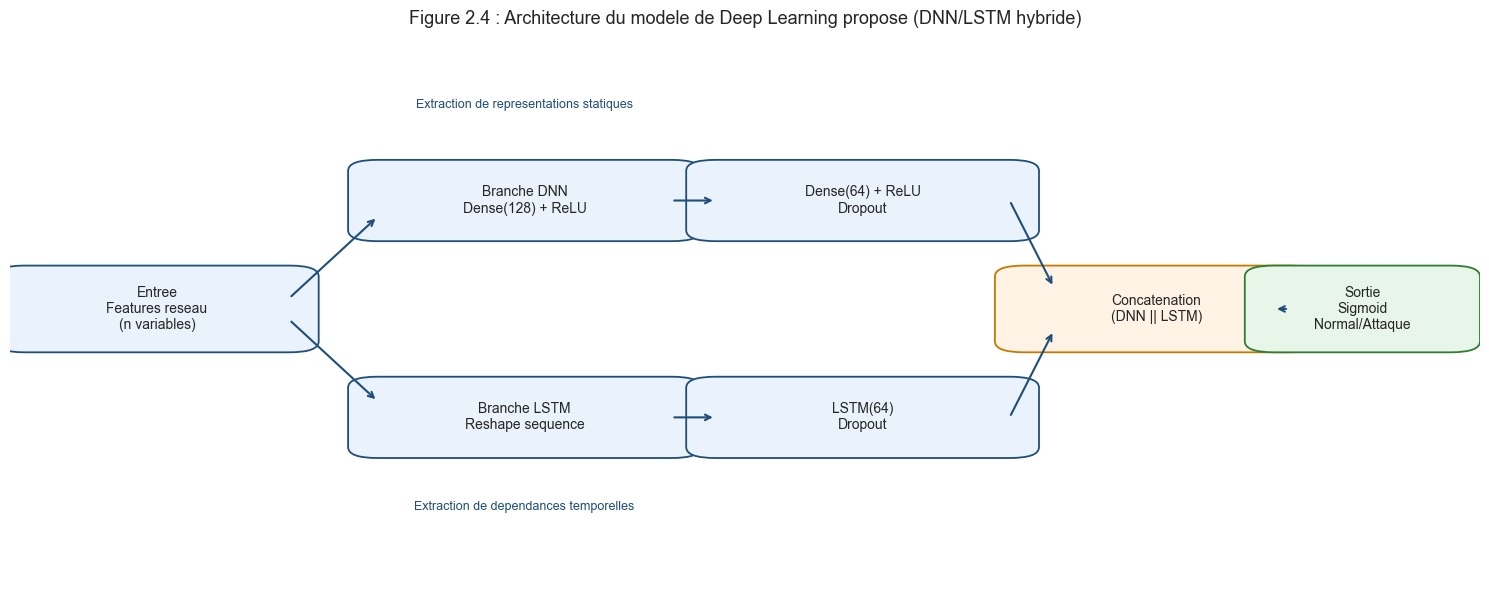

In [9]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')


def add_block(x, y, w, h, text, fc='#EAF2FB', ec='#1F4E79', fs=10):
    block = FancyBboxPatch(
        (x - w / 2, y - h / 2),
        w,
        h,
        boxstyle='round,pad=0.02,rounding_size=0.02',
        linewidth=1.3,
        edgecolor=ec,
        facecolor=fc
    )
    ax.add_patch(block)
    ax.text(x, y, text, ha='center', va='center', fontsize=fs)


def add_arrow(x1, y1, x2, y2, color='#1F4E79'):
    ax.annotate(
        '',
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', lw=1.5, color=color)
    )

# Entree commune
add_block(0.10, 0.50, 0.18, 0.12, 'Entree\nFeatures reseau\n(n variables)')

# Branche DNN
add_block(0.35, 0.70, 0.20, 0.11, 'Branche DNN\nDense(128) + ReLU')
add_block(0.58, 0.70, 0.20, 0.11, 'Dense(64) + ReLU\nDropout')

# Branche LSTM
add_block(0.35, 0.30, 0.20, 0.11, 'Branche LSTM\nReshape sequence')
add_block(0.58, 0.30, 0.20, 0.11, 'LSTM(64)\nDropout')

# Fusion et sortie
add_block(0.78, 0.50, 0.18, 0.12, 'Concatenation\n(DNN || LSTM)', fc='#FFF3E6', ec='#C47A00')
add_block(0.92, 0.50, 0.12, 0.12, 'Sortie\nSigmoid\nNormal/Attaque', fc='#E8F5E9', ec='#2E7D32')

# Fleches entree vers branches
add_arrow(0.19, 0.52, 0.25, 0.67)
add_arrow(0.19, 0.48, 0.25, 0.33)

# Fleches internes branches
add_arrow(0.45, 0.70, 0.48, 0.70)
add_arrow(0.45, 0.30, 0.48, 0.30)

# Fleches vers fusion
add_arrow(0.68, 0.70, 0.71, 0.54)
add_arrow(0.68, 0.30, 0.71, 0.46)

# Fleche fusion vers sortie
add_arrow(0.87, 0.50, 0.86, 0.50)

# Notes techniques
ax.text(0.35, 0.87, 'Extraction de representations statiques', fontsize=9, color='#1F4E79', ha='center')
ax.text(0.35, 0.13, 'Extraction de dependances temporelles', fontsize=9, color='#1F4E79', ha='center')

ax.set_title('Figure 2.4 : Architecture du modele de Deep Learning propose (DNN/LSTM hybride)', fontsize=13, pad=10)
plt.tight_layout()
plt.show()